<a href="https://colab.research.google.com/github/frank-morales2020/Cloud_curious/blob/master/Aviation_AGI_LEJEPA_OpenSource_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️  Aviation AGI — Full Open-Source Integration
## LEJEPA World Model × Open-Source LLM × V-JEPA × MPPI Planner

**Fully open-source stack**

| Component | Model / Lib | License |
|---|---|---|
| Video Encoder | `facebook/vjepa2-vitg-fpc64-256` | CC-BY-NC 4.0 |
| World Model | LEJEPA + SIGReg + EMA | This notebook (Apache 2.0) |
| LLM | `mistralai/Mistral-7B-Instruct-v0.3` | Apache 2.0 |
| LLM fallback | `microsoft/phi-2` | MIT |
| Visual (Cell 4) | `openai/clip-vit-base-patch32` | MIT |
| Data | TartanAviation ADS-B + Vision | CC-BY 4.0 |
| Planner | MPPI in LEJEPA latent space | This notebook |

Reference: [lejepa GitHub](https://github.com/rbalestr-lab/lejepa)


In [ ]:
!nvidia-smi

Sun May 10 00:31:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   29C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── CELL 1: Installation ─────────────────────────────────────────────────────
!pip install av torch torchvision transformers>=4.40 accelerate bitsandbytes -q
!pip install sentencepiece einops scipy pandas numpy tqdm pytz huggingface_hub -q
!pip install minio boto3 -q
!apt-get install -y ffmpeg unzip -q
print("✅ Installation complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 142.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 112.7 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
unzip is already the newest version (6.0-26ubuntu3.2).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.
✅ Installation complete.


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# ── CELL 2: Imports & Global Configuration ───────────────────────────────────
import os, gc, json, random, logging, datetime, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import pytz
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s",
                    datefmt="%H:%M:%S")
logger = logging.getLogger("AviationAGI")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {device}")


@dataclass
class AviationAGIConfig:
    # Models
    vjepa_repo:   str = "facebook/vjepa2-vitg-fpc64-256"
    llm_repo:     str = "mistralai/Mistral-7B-Instruct-v0.3"
    llm_fallback: str = "microsoft/phi-2"
    clip_repo:    str = "openai/clip-vit-base-patch32"

    # LEJEPA World Model
    state_dim:     int   = 4
    visual_dim:    int   = 1408
    latent_dim:    int   = 64
    action_dim:    int   = 8
    ema_decay:     float = 0.996
    sigreg_lambda: float = 5.0

    # Training
    lr:         float = 1e-3
    batch_size: int   = 64
    wm_epochs:  int   = 10
    cls_epochs: int   = 20

    # MPPI Planning
    plan_horizon:  int = 50
    plan_samples:  int = 200

    # Data paths
    adsb_dir:     str = "/content/adsb/kbtp/raw/2022"
    features_dir: str = "/content/gdrive/MyDrive/datasets/TartanAviation_VJEPA_Features/"
    video_path:   str = "/content/gdrive/MyDrive/datasets/TartanAviation/vision/1_2023-02-22-15-21-49/1_2023-02-22-15-21-49.mp4"

    flight_phases: List[str] = field(default_factory=lambda: [
        "airplane landing", "airplane takeoff", "airport ground operations",
        "in-flight cruise", "emergency landing", "pre-flight check/maintenance",
        "en-route cruise", "climb phase", "descent phase", "holding pattern",
    ])
    airports: Dict = field(default_factory=lambda: {
        "CYUL": {"name": "Montreal-Trudeau Intl", "lat": 45.4706, "lon": -73.7408, "elev_ft": 118},
        "LFPG": {"name": "Paris-CDG Intl",        "lat": 49.0097, "lon":   2.5479, "elev_ft": 392},
        "KJFK": {"name": "New York-JFK Intl",     "lat": 40.6413, "lon": -73.7781, "elev_ft":  13},
        "EGLL": {"name": "London Heathrow Intl",  "lat": 51.4700, "lon":  -0.4543, "elev_ft":  83},
        "RJTT": {"name": "Tokyo Haneda Intl",     "lat": 35.5494, "lon": 139.7798, "elev_ft":  21},
    })
    aircraft: Dict = field(default_factory=lambda: {
        "B77W": {"name": "Boeing 777-300ER", "cruise_kts": 490, "cruise_altitude_ft": 37000,
                 "fuel_kg_hr": 7000, "range_nm": 7930, "fuel_cap_kg": 145000,
                 "climb_rate_fpm": 2500, "descent_rate_fpm": 2000},
        "A359": {"name": "Airbus A350-900",  "cruise_kts": 488, "cruise_altitude_ft": 39000,
                 "fuel_kg_hr": 5800, "range_nm": 8100, "fuel_cap_kg": 141000,
                 "climb_rate_fpm": 2800, "descent_rate_fpm": 2200},
        "B789": {"name": "Boeing 787-9",     "cruise_kts": 487, "cruise_altitude_ft": 40000,
                 "fuel_kg_hr": 5600, "range_nm": 7635, "fuel_cap_kg": 126920,
                 "climb_rate_fpm": 2600, "descent_rate_fpm": 2100},
    })


cfg = AviationAGIConfig()
logger.info(f"Config loaded | phases={len(cfg.flight_phases)} | airports={len(cfg.airports)}")

## 🧠 Cell 3 — LEJEPA World Model (Full Implementation)

**Loss:**
$$\mathcal{L}_{\text{LEJEPA}} = \underbrace{\|\hat{z}_{t+1} - \bar{z}_{t+1}\|_2^2}_{\text{JEPA}} + \underbrace{\lambda(\|\mathbb{E}[z]\| + \|\sigma(z)-1\| + \|C_z - I\|_F)}_{\mathcal{L}_{\text{SIGReg}}}$$

SIGReg enforces $z \sim \mathcal{N}(0,I)$ — eliminates collapse with no heuristics.


In [ ]:
# ── CELL 3: LEJEPA World Model ───────────────────────────────────────────────

class SIGReg(nn.Module):
    """Sketched Isotropic Gaussian Regularization — LEJEPA's core innovation."""
    def __init__(self, lambda_reg: float = 5.0, sketch_dim: int = 256):
        super().__init__()
        self.lam, self.sketch_dim = lambda_reg, sketch_dim

    def forward(self, z: torch.Tensor) -> Tuple[torch.Tensor, Dict]:
        B, D = z.shape
        zs = z @ (torch.randn(D, self.sketch_dim, device=z.device) / self.sketch_dim**0.5) \
             if D > self.sketch_dim else z

        mean_pen = torch.norm(zs.mean(0))
        std_pen  = torch.norm(zs.std(0) - 1.0)

        if B > 1:
            zc   = zs - zs.mean(0, keepdim=True)
            znm  = F.normalize(zc, dim=0)
            cov  = (znm.T @ znm) / B
            corr_pen = torch.norm(cov - torch.eye(cov.shape[0], device=z.device), p="fro")
        else:
            corr_pen = z.new_zeros(1).squeeze()

        loss = self.lam * (mean_pen + std_pen + 0.1 * corr_pen)
        return loss, {"sigreg/mean": mean_pen.item(), "sigreg/std": std_pen.item(),
                      "sigreg/corr": corr_pen.item(), "sigreg/total": loss.item()}


class LEJEPAEncoder(nn.Module):
    """Context encoder: state → latent z (trained via backprop)."""
    def __init__(self, input_dim: int, latent_dim: int, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),    nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, latent_dim), nn.LayerNorm(latent_dim),
        )
    def forward(self, x):
        return self.net(x.unsqueeze(0) if x.dim() == 1 else x)


class LEJEPAPredictor(nn.Module):
    """Causal predictor: (z_t, a_t) → ẑ_{t+1} — the world model forward pass."""
    def __init__(self, latent_dim: int, action_dim: int, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + action_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),                  nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, latent_dim),
        )
    def forward(self, z, a):
        z = z.unsqueeze(0) if z.dim() == 1 else z
        a = a.unsqueeze(0) if a.dim() == 1 else a
        return self.net(torch.cat([z, a], dim=-1))


class LEJEPAWorldModel(nn.Module):
    """
    Full LEJEPA World Model with EMA Target Encoder.

      ContextEncoder (θ)  ← gradient descent
      TargetEncoder  (θ̄)  ← EMA: θ̄ ← τθ̄ + (1-τ)θ   (no grad)
      Predictor      (φ)  ← (z_ctx, a) → ẑ_tgt

      L = MSE(ẑ, sg(z̄)) + SIGReg(ẑ) + SIGReg(z_ctx)
    """
    def __init__(self, input_dim, latent_dim, action_dim,
                 ema_decay=0.996, sigreg_lambda=5.0):
        super().__init__()
        self.ema_decay   = ema_decay
        self.ctx_encoder = LEJEPAEncoder(input_dim, latent_dim)
        self.tgt_encoder = LEJEPAEncoder(input_dim, latent_dim)
        self.predictor   = LEJEPAPredictor(latent_dim, action_dim)
        self.sigreg      = SIGReg(lambda_reg=sigreg_lambda)
        self._sync_target()
        for p in self.tgt_encoder.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def _sync_target(self):
        for pc, pt in zip(self.ctx_encoder.parameters(), self.tgt_encoder.parameters()):
            pt.data.copy_(pc.data)

    @torch.no_grad()
    def ema_update(self):
        t = self.ema_decay
        for pc, pt in zip(self.ctx_encoder.parameters(), self.tgt_encoder.parameters()):
            pt.data.mul_(t).add_(pc.data, alpha=1.0 - t)

    def forward(self, s_t, s_tp1, a_t) -> Tuple[torch.Tensor, Dict]:
        z_ctx  = self.ctx_encoder(s_t)
        with torch.no_grad():
            z_tgt = self.tgt_encoder(s_tp1)
        z_pred = self.predictor(z_ctx, a_t)

        jepa_loss      = F.mse_loss(z_pred, z_tgt.detach())
        sr_pred, m_pred = self.sigreg(z_pred)
        sr_ctx,  m_ctx  = self.sigreg(z_ctx)
        total = jepa_loss + sr_pred + sr_ctx

        return total, {
            "loss/total":    total.item(),
            "loss/jepa":     jepa_loss.item(),
            "loss/sr_pred":  m_pred["sigreg/total"],
            "loss/sr_ctx":   m_ctx["sigreg/total"],
            "sigreg/mean":   m_pred["sigreg/mean"],
            "sigreg/std":    m_pred["sigreg/std"],
        }

    @torch.no_grad()
    def encode(self, s: torch.Tensor) -> torch.Tensor:
        return self.ctx_encoder(s)

    @torch.no_grad()
    def step(self, z: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.predictor(z, a)


world_model = LEJEPAWorldModel(
    input_dim=cfg.state_dim, latent_dim=cfg.latent_dim,
    action_dim=cfg.action_dim, ema_decay=cfg.ema_decay,
    sigreg_lambda=cfg.sigreg_lambda,
).to(device)
logger.info(f"LEJEPA WM params: {sum(p.numel() for p in world_model.parameters()):,}")


## 🎬 Cell 4 — V-JEPA Visual Encoder + Multi-Modal Cross-Attention Fusion

**Visual stream**: V-JEPA video encoder → pool patches → `[1, 1408]`  
**Navigation stream**: ADS-B state `[4D]` → projected  
**Fusion**: cross-attention (visual queries nav) + MLP → `[latent_dim]`


In [ ]:
# ── CELL 4: V-JEPA Visual Encoder & Multi-Modal Fusion ───────────────────────

class VJEPAEncoder:
    """Wraps facebook/vjepa2-vitg-fpc64-256 for video feature extraction."""
    def __init__(self, repo: str = "facebook/vjepa2-vitg-fpc64-256", device=None):
        from transformers import AutoVideoProcessor, AutoModel
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        logger.info(f"Loading V-JEPA2 from {repo} …")
        self.processor = AutoVideoProcessor.from_pretrained(repo)
        self.model     = AutoModel.from_pretrained(repo).to(self.device).eval()
        logger.info("V-JEPA2 ready.")

    @torch.no_grad()
    def extract(self, video_path: str, num_frames: int = 16) -> Optional[torch.Tensor]:
        """Returns raw [1, T*P, 1408] features, or None on failure."""
        try:
            import av
            frames, container = [], av.open(video_path)
            total = container.streams.video[0].frames
            step  = max(1, total // num_frames)
            for i, frm in enumerate(container.decode(video=0)):
                if len(frames) >= num_frames: break
                if i % step == 0: frames.append(frm.to_rgb().to_ndarray())
            if not frames: return None
            inputs = self.processor(videos=frames, return_tensors="pt")
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            return self.model(**inputs).last_hidden_state
        except Exception as e:
            logger.error(f"V-JEPA error: {e}")
            return None

    def pool(self, features: torch.Tensor) -> torch.Tensor:
        """[1, T*P, 1408] → [1, 1408] mean pooling."""
        return features.squeeze(0).mean(0, keepdim=True)


class MultiModalAviationEncoder(nn.Module):
    """Cross-attention fusion of V-JEPA visual and ADS-B navigation streams."""
    def __init__(self, visual_dim: int = 1408, nav_dim: int = 4,
                 latent_dim: int = 64, num_heads: int = 4):
        super().__init__()
        self.vis_proj = nn.Sequential(
            nn.Linear(visual_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, latent_dim), nn.LayerNorm(latent_dim),
        )
        self.nav_proj = nn.Sequential(
            nn.Linear(nav_dim, 64), nn.LayerNorm(64), nn.GELU(),
            nn.Linear(64, latent_dim), nn.LayerNorm(latent_dim),
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=latent_dim, num_heads=num_heads, batch_first=True)
        self.fuse = nn.Sequential(
            nn.Linear(latent_dim * 2, latent_dim),
            nn.LayerNorm(latent_dim), nn.GELU(),
            nn.Linear(latent_dim, latent_dim),
        )

    def forward(self, visual: Optional[torch.Tensor] = None,
                nav: Optional[torch.Tensor] = None) -> torch.Tensor:
        feats = []
        if visual is not None: feats.append(self.vis_proj(visual))
        if nav    is not None: feats.append(self.nav_proj(nav))
        if not feats: raise ValueError("At least one modality required.")
        if len(feats) == 1:   return feats[0]
        v, n = feats[0].unsqueeze(1), feats[1].unsqueeze(1)
        attn, _ = self.cross_attn(v, n, n)
        return self.fuse(torch.cat([attn.squeeze(1), feats[1]], dim=-1))


mm_encoder = MultiModalAviationEncoder(
    visual_dim=cfg.visual_dim, nav_dim=cfg.state_dim, latent_dim=cfg.latent_dim
).to(device)
logger.info(f"MultiModal Encoder params: {sum(p.numel() for p in mm_encoder.parameters()):,}")


## 📡 Cell 5 — ADS-B Data Pipeline

Loads real ADS-B CSVs from TartanAviation. Falls back to **physically plausible synthetic trajectories**.

Each sample `(s_t, a_t, s_{t+1})`:
- `s = [Lat, Lon, Altitude_ft, Speed_kts]`  
- `a = [ΔSpeed, ΔAlt, ΔLat, ΔLon, 0, 0, 0, 0]`


In [ ]:
# ── CELL 5: ADS-B Data Pipeline ──────────────────────────────────────────────

class ADSBDataset(Dataset):
    REQUIRED = ["Lat", "Lon", "Altitude", "Speed"]

    def __init__(self, data_dir: str, device,
                 max_files: int = 50, max_traj: int = 200):
        self.samples: List[Tuple] = []
        self._load(data_dir, max_files, max_traj)

    def _load(self, data_dir, max_files, max_traj):
        files = list(Path(data_dir).rglob("*.csv"))[:max_files]
        if not files:
            logger.warning(f"No CSVs in '{data_dir}'. Generating synthetic data.")
            self._synthetic(); return

        logger.info(f"Loading {len(files)} ADS-B files …")
        for fp in tqdm(files, desc="ADS-B"):
            try:
                df = pd.read_csv(fp, on_bad_lines="skip", engine="python")
                if not all(c in df.columns for c in self.REQUIRED): continue
                for c in self.REQUIRED:
                    df[c] = pd.to_numeric(df[c], errors="coerce")
                df.dropna(subset=self.REQUIRED, inplace=True)
                if len(df) < 2: continue
                groups = list(df.groupby("Tail"))[:max_traj] \
                         if "Tail" in df.columns else [(0, df)]
                for _, traj in groups:
                    traj = traj.reset_index(drop=True)
                    for i in range(len(traj) - 1):
                        s  = traj.iloc[i][self.REQUIRED].values.astype(np.float32)
                        sp = traj.iloc[i+1][self.REQUIRED].values.astype(np.float32)
                        if np.any(np.isnan(s)) or np.any(np.isnan(sp)): continue
                        a = np.array([sp[3]-s[3], sp[2]-s[2], sp[0]-s[0], sp[1]-s[1],
                                      0., 0., 0., 0.], dtype=np.float32)
                        self.samples.append((s, a, sp))
            except Exception as e:
                logger.debug(f"Skipped {fp}: {e}")

        if not self.samples:
            logger.warning("No real ADS-B samples loaded. Falling back to synthetic.")
            self._synthetic()
        else:
            logger.info(f"Loaded {len(self.samples):,} real ADS-B transitions.")

    def _synthetic(self, n_traj: int = 2000, traj_len: int = 30):
        phases = {
            "takeoff":  np.array([45.47, -73.74,    500.,  200.], dtype=np.float32),
            "climb":    np.array([46.00, -70.00,  15000.,  380.], dtype=np.float32),
            "cruise":   np.array([47.00, -55.00,  37000.,  490.], dtype=np.float32),
            "descent":  np.array([48.50,   0.50,  12000.,  350.], dtype=np.float32),
            "approach": np.array([49.01,   2.55,   1000.,  160.], dtype=np.float32),
        }
        for _ in range(n_traj):
            state = random.choice(list(phases.values())).copy() \
                  + np.random.randn(4).astype(np.float32) * [0.05, 0.05, 50., 5.]
            for _ in range(traj_len):
                dv, dalt = np.random.uniform(-15., 15.), np.random.uniform(-300., 300.)
                a  = np.array([dv, dalt, 0., 0., 0., 0., 0., 0.], dtype=np.float32)
                ns = state.copy()
                ns[2] = np.clip(state[2] + dalt, 0., 43100.)
                ns[3] = np.clip(state[3] + dv,   0., 600.)
                self.samples.append((state, a, ns)); state = ns
        logger.info(f"Generated {len(self.samples):,} synthetic transitions.")

    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        s, a, sp = self.samples[i]
        return torch.from_numpy(s), torch.from_numpy(a), torch.from_numpy(sp)


dataset = ADSBDataset(cfg.adsb_dir, device=device, max_files=20)
logger.info(f"Dataset: {len(dataset):,} transitions")


## 🏋️ Cell 6 — Train LEJEPA World Model

- **Gradient clipping** (norm ≤ 1.0)
- **Cosine LR schedule**
- **EMA update** after every `optimizer.step()`
- Full SIGReg penalty logging (mean / std / corr)


In [ ]:
import os, gc, json, random, logging, datetime, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import pytz
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s",
                    datefmt="%H:%M:%S")
logger = logging.getLogger("AviationAGI")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {device}")


@dataclass
class AviationAGIConfig:
    # Models
    vjepa_repo:   str = "facebook/vjepa2-vitg-fpc64-256"
    llm_repo:     str = "mistralai/Mistral-7B-Instruct-v0.3"
    llm_fallback: str = "microsoft/phi-2"
    clip_repo:    str = "openai/clip-vit-base-patch32"

    # LEJEPA World Model
    state_dim:     int   = 4
    visual_dim:    int   = 1408
    latent_dim:    int   = 64
    action_dim:    int   = 8
    ema_decay:     float = 0.996
    sigreg_lambda: float = 5.0

    # Training
    lr:         float = 1e-3
    batch_size: int   = 64
    wm_epochs:  int   = 10
    cls_epochs: int   = 20

    # MPPI Planning
    plan_horizon:  int = 50
    plan_samples:  int = 200

    # Data paths
    adsb_dir:     str = "/content/adsb/kbtp/raw/2022"
    features_dir: str = "/content/gdrive/MyDrive/datasets/TartanAviation_VJEPA_Features/"
    video_path:   str = "/content/gdrive/MyDrive/datasets/TartanAviation/vision/1_2023-02-22-15-21-49/1_2023-02-22-15-21-49.mp4"

    flight_phases: List[str] = field(default_factory=lambda: [
        "airplane landing", "airplane takeoff", "airport ground operations",
        "in-flight cruise", "emergency landing", "pre-flight check/maintenance",
        "en-route cruise", "climb phase", "descent phase", "holding pattern",
    ])
    airports: Dict = field(default_factory=lambda: {
        "CYUL": {"name": "Montreal-Trudeau Intl", "lat": 45.4706, "lon": -73.7408, "elev_ft": 118},
        "LFPG": {"name": "Paris-CDG Intl",        "lat": 49.0097, "lon":   2.5479, "elev_ft": 392},
        "KJFK": {"name": "New York-JFK Intl",     "lat": 40.6413, "lon": -73.7781, "elev_ft":  13},
        "EGLL": {"name": "London Heathrow Intl",  "lat": 51.4700, "lon":  -0.4543, "elev_ft":  83},
        "RJTT": {"name": "Tokyo Haneda Intl",     "lat": 35.5494, "lon": 139.7798, "elev_ft":  21},
    })
    aircraft: Dict = field(default_factory=lambda: {
        "B77W": {"name": "Boeing 777-300ER", "cruise_kts": 490, "cruise_altitude_ft": 37000,
                 "fuel_kg_hr": 7000, "range_nm": 7930, "fuel_cap_kg": 145000,
                 "climb_rate_fpm": 2500, "descent_rate_fpm": 2000},
        "A359": {"name": "Airbus A350-900",  "cruise_kts": 488, "cruise_altitude_ft": 39000,
                 "fuel_kg_hr": 5800, "range_nm": 8100, "fuel_cap_kg": 141000,
                 "climb_rate_fpm": 2800, "descent_rate_fpm": 2200},
        "B789": {"name": "Boeing 787-9",     "cruise_kts": 487, "cruise_altitude_ft": 40000,
                 "fuel_kg_hr": 5600, "range_nm": 7635, "fuel_cap_kg": 126920,
                 "climb_rate_fpm": 2600, "descent_rate_fpm": 2100},
    })


cfg = AviationAGIConfig()
logger.info(f"Config loaded | phases={len(cfg.flight_phases)} | airports={len(cfg.airports)}")

# ── CELL 6: Train LEJEPA World Model ────────────────────────────────────────

def train_world_model(wm, dataset, epochs=10, lr=1e-3, batch_size=64):
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    trainable = list(wm.ctx_encoder.parameters()) + list(wm.predictor.parameters())
    opt      = optim.Adam(trainable, lr=lr, weight_decay=1e-4)
    sch      = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/10)
    history  = []

    logger.info(f"\n=== Training LEJEPA: {epochs} epochs × {len(loader)} batches ===")
    for epoch in range(epochs):
        wm.train(); wm.tgt_encoder.eval()
        accum: Dict[str, list] = {}

        for s_t, a_t, s_tp1 in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            # Explicitly cast tensors to float32 to match model parameters
            s_t, a_t, s_tp1 = s_t.to(device).float(), a_t.to(device).float(), s_tp1.to(device).float()
            loss, metrics = wm(s_t, s_tp1, a_t)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(wm.parameters(), 1.0)
            opt.step(); wm.ema_update()
            for k, v in metrics.items():
                accum.setdefault(k, []).append(v)

        sch.step()
        avg = {k: float(np.mean(v)) for k, v in accum.items()}
        history.append(avg)
        logger.info(
            f"Ep {epoch+1:02d}/{epochs} | "
            f"Total={avg['loss/total']:.5f}  JEPA={avg['loss/jepa']:.5f}  "
            f"SIGReg(pred)={avg['loss/sr_pred']:.5f}  SIGReg(ctx)={avg['loss/sr_ctx']:.5f}  "
            f"mean_pen={avg['sigreg/mean']:.5f}  std_pen={avg['sigreg/std']:.5f}"
        )

    torch.save(wm.state_dict(), "lejepa_world_model.pth")
    logger.info("✅ World Model saved → lejepa_world_model.pth")
    return history


wm_history = train_world_model(world_model, dataset,
                                epochs=cfg.wm_epochs, lr=cfg.lr,
                                batch_size=cfg.batch_size)

Epoch 1/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/937 [00:00<?, ?it/s]

## 🔍 Cell 7 — Flight Phase Classifier

3-layer MLP on pooled V-JEPA `[1408D]` features. Trained on real features when available, otherwise 50 k synthetic samples.


In [ ]:
import os, gc, json, random, logging, datetime, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import pytz
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s",
                    datefmt="%H:%M:%S")
logger = logging.getLogger("AviationAGI")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {device}")


@dataclass
class AviationAGIConfig:
    # Models
    vjepa_repo:   str = "facebook/vjepa2-vitg-fpc64-256"
    llm_repo:     str = "mistralai/Mistral-7B-Instruct-v0.3"
    llm_fallback: str = "microsoft/phi-2"
    clip_repo:    str = "openai/clip-vit-base-patch32"

    # LEJEPA World Model
    state_dim:     int   = 4
    visual_dim:    int   = 1408
    latent_dim:    int   = 64
    action_dim:    int   = 8
    ema_decay:     float = 0.996
    sigreg_lambda: float = 5.0

    # Training
    lr:         float = 1e-3
    batch_size: int   = 64
    wm_epochs:  int   = 10
    cls_epochs: int   = 20

    # MPPI Planning
    plan_horizon:  int = 50
    plan_samples:  int = 200

    # Data paths
    adsb_dir:     str = "/content/adsb/kbtp/raw/2022"
    features_dir: str = "/content/gdrive/MyDrive/datasets/TartanAviation_VJEPA_Features/"
    video_path:   str = "/content/gdrive/MyDrive/datasets/TartanAviation/vision/1_2023-02-22-15-21-49/1_2023-02-22-15-21-49.mp4"

    flight_phases: List[str] = field(default_factory=lambda: [
        "airplane landing", "airplane takeoff", "airport ground operations",
        "in-flight cruise", "emergency landing", "pre-flight check/maintenance",
        "en-route cruise", "climb phase", "descent phase", "holding pattern",
    ])
    airports: Dict = field(default_factory=lambda: {
        "CYUL": {"name": "Montreal-Trudeau Intl", "lat": 45.4706, "lon": -73.7408, "elev_ft": 118},
        "LFPG": {"name": "Paris-CDG Intl",        "lat": 49.0097, "lon":   2.5479, "elev_ft": 392},
        "KJFK": {"name": "New York-JFK Intl",     "lat": 40.6413, "lon": -73.7781, "elev_ft":  13},
        "EGLL": {"name": "London Heathrow Intl",  "lat": 51.4700, "lon":  -0.4543, "elev_ft":  83},
        "RJTT": {"name": "Tokyo Haneda Intl",     "lat": 35.5494, "lon": 139.7798, "elev_ft":  21},
    })
    aircraft: Dict = field(default_factory=lambda: {
        "B77W": {"name": "Boeing 777-300ER", "cruise_kts": 490, "cruise_altitude_ft": 37000,
                 "fuel_kg_hr": 7000, "range_nm": 7930, "fuel_cap_kg": 145000,
                 "climb_rate_fpm": 2500, "descent_rate_fpm": 2000},
        "A359": {"name": "Airbus A350-900",  "cruise_kts": 488, "cruise_altitude_ft": 39000,
                 "fuel_kg_hr": 5800, "range_nm": 8100, "fuel_cap_kg": 141000,
                 "climb_rate_fpm": 2800, "descent_rate_fpm": 2200},
        "B789": {"name": "Boeing 787-9",     "cruise_kts": 487, "cruise_altitude_ft": 40000,
                 "fuel_kg_hr": 5600, "range_nm": 7635, "fuel_cap_kg": 126920,
                 "climb_rate_fpm": 2600, "descent_rate_fpm": 2100},
    })


cfg = AviationAGIConfig()
logger.info(f"Config loaded | phases={len(cfg.flight_phases)} | airports={len(cfg.airports)}")

# ── CELL 7: Flight Phase Classifier ─────────────────────────────────────────

num_classes = len(cfg.flight_phases)

class FlightPhaseClassifier(nn.Module):
    def __init__(self, feat_dim: int = 1408, num_classes: int = 10, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),      nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.net(x)


classifier = FlightPhaseClassifier(1408, num_classes).to(device)
logger.info(f"Classifier params: {sum(p.numel() for p in classifier.parameters()):,}")


def train_classifier(clf, features_dir, epochs=20, batch_size=256):
    feats_list, labels_list = [], []
    map_path = Path(features_dir) / "feature_label_map.json"

    if map_path.exists():
        with open(map_path) as f:
            fmap = json.load(f)
        for item in tqdm(fmap, desc="Loading features", leave=False):
            try:
                fp   = item["feature_path"]
                if not Path(fp).is_absolute(): fp = str(Path(features_dir) / fp)
                feat = torch.load(fp, map_location="cpu")
                if feat.ndim == 3:   feat = feat.squeeze(0).mean(0)
                elif feat.ndim == 2: feat = feat.mean(0)
                if feat.shape[0] != 1408: continue
                feats_list.append(feat)
                labels_list.append(int(item["label_idx"]))
            except Exception: pass

    # Fix: Ensure enough samples for batching or fall back to synthetic data
    if feats_list and len(feats_list) >= batch_size:
        X, y = torch.stack(feats_list), torch.tensor(labels_list)
        logger.info(f"Classifier: {len(X):,} REAL V-JEPA features.")
    else:
        if feats_list: # Some real features were found, but not enough for batching
            logger.warning(f"Found {len(feats_list)} real V-JEPA features, which is less than batch_size={batch_size}. Generating synthetic data.")
        else: # No real features were found
            logger.warning("No real V-JEPA features found. Generating synthetic data.")
        N = 50_000
        X, y = torch.rand(N, 1408), torch.randint(0, num_classes, (N,)) # Always generate a substantial number
        logger.info(f"Classifier: {N:,} SYNTHETIC samples.")

    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True, drop_last=True)
    opt    = optim.Adam(clf.parameters(), lr=1e-3, weight_decay=1e-4)
    sch    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit   = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        clf.train()
        total_loss, correct, total = 0., 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = clf(xb)
            loss   = crit(logits, yb); loss.backward(); opt.step()
            total_loss += loss.item() * len(xb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(xb)
        sch.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            # Prevent ZeroDivisionError if total is 0 (should not happen with fix)
            if total > 0:
                logger.info(f"  Cls {epoch+1:02d}/{epochs} | loss={total_loss/total:.4f} | acc={correct/total:.3f}")
            else:
                logger.info(f"  Cls {epoch+1:02d}/{epochs} | No data processed in this epoch.")

    torch.save(clf.state_dict(), "aviation_agi_classifier.pth")
    logger.info("✅ Classifier saved → aviation_agi_classifier.pth")
    return clf


classifier = train_classifier(classifier, cfg.features_dir, epochs=cfg.cls_epochs)


Loading features:   0%|          | 0/1 [00:00<?, ?it/s]

## 💬 Cell 8 — Open-Source LLM Reasoning Engine

**Primary**: `mistralai/Mistral-7B-Instruct-v0.3` (Apache 2.0) — 4-bit NF4 quantized  
**Fallback**: `microsoft/phi-2` (MIT) — runs on <8 GB VRAM

Three reasoning tools the LLM provides:
1. **Phase interpreter** — chain-of-thought operational assessment
2. **Route planner** — translates MPPI action sequences into prose flight plans
3. **Anomaly detector** — classifies world-model prediction errors


In [ ]:
# ── CELL 8: Open-Source LLM Reasoning Engine ─────────────────────────────────

class OpenSourceLLMEngine:
    """
    Open-source LLM integration for aviation chain-of-thought reasoning.

    Primary:  Mistral-7B-Instruct-v0.3 (Apache 2.0) — 4-bit quantized
    Fallback: microsoft/phi-2           (MIT)          — <8 GB VRAM

    Tools:
      • interpret_phase     — operational assessment of V-JEPA classification
      • generate_flight_plan — MPPI actions → prose flight plan
      • detect_anomaly       — world-model prediction error analysis
    """
    def __init__(self, repo: str = "mistralai/Mistral-7B-Instruct-v0.3",
                 use_4bit: bool = True, device=None):
        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
        self.repo = repo
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        logger.info(f"Loading LLM: {repo} ({'4-bit NF4' if use_4bit else 'fp16'}) …")

        self.tokenizer = AutoTokenizer.from_pretrained(repo, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        quant_cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                       bnb_4bit_use_double_quant=True,
                                       bnb_4bit_compute_dtype=torch.float16) \
                    if use_4bit and torch.cuda.is_available() else None
        self.llm = AutoModelForCausalLM.from_pretrained(
            repo,
            quantization_config=quant_cfg,
            torch_dtype=None if use_4bit else torch.float16,
            device_map="auto", trust_remote_code=True,
        ).eval()
        logger.info("✅ LLM ready.")

    def _prompt(self, system: str, user: str) -> str:
        if "mistral" in self.repo.lower():
            return f"[INST] {system}\n\n{user} [/INST]"
        if "llama"   in self.repo.lower():
            return f"<|system|>\n{system}<|end|>\n<|user|>\n{user}<|end|>\n<|assistant|>"
        return f"System: {system}\nUser: {user}\nAssistant:"

    @torch.no_grad()
    def generate(self, prompt: str, max_new_tokens: int = 512, temp: float = 0.3) -> str:
        enc = self.tokenizer(prompt, return_tensors="pt").to(self.llm.device)
        out = self.llm.generate(**enc, max_new_tokens=max_new_tokens,
                                temperature=temp, do_sample=(temp > 0),
                                pad_token_id=self.tokenizer.eos_token_id)
        return self.tokenizer.decode(out[0][enc["input_ids"].shape[1]:],
                                     skip_special_tokens=True).strip()

    # ── Tool 1: Phase Interpreter ──────────────────────────────────────────────
    def interpret_phase(self, phase: str, confidence: float,
                        aircraft: str, origin: Dict, dest: Dict) -> str:
        sys = ("You are an expert aviation AI in an AGI flight management system. "
               "Be concise, technical, safety-focused. ICAO terminology. No filler.")
        usr = (f"VISUAL OBSERVATION:\n"
               f"  Phase: {phase} (confidence {confidence:.1%})\n"
               f"  Aircraft: {aircraft}\n"
               f"  Route: {origin['name']} → {dest['name']}\n"
               f"  UTC: {datetime.datetime.now(pytz.utc).strftime('%Y-%m-%dT%H:%M:%SZ')}\n\n"
               f"Provide 3-part assessment (≤120 words):\n"
               f"  1. PHASE INTERPRETATION\n  2. SAFETY CHECK\n  3. NEXT FMS ACTION")
        return self.generate(self._prompt(sys, usr), max_new_tokens=200, temp=0.2)

    # ── Tool 2: Route Planner ──────────────────────────────────────────────────
    def generate_flight_plan(self, origin: Dict, dest: Dict, aircraft: Dict,
                              actions: List[np.ndarray], phase: str) -> str:
        steps = "\n".join(
            f"  Step {i+1:02d}: ΔSpd={a[0]:+.1f} kts  ΔAlt={a[1]:+.0f} ft"
            for i, a in enumerate(actions[:10])
        )
        sys = ("You are an aviation AGI flight planning module. "
               "Translate world-model outputs into structured flight plans. "
               "Standard ICAO/FAA phraseology. Specific altitudes, speeds, headings.")
        usr = (f"ROUTE: {origin['name']} ({origin.get('icao','?')}) → "
               f"{dest['name']} ({dest.get('icao','?')})\n"
               f"Aircraft: {aircraft['name']}  "
               f"FL{aircraft.get('cruise_altitude_ft',37000)//100:03d}  "
               f"{aircraft.get('cruise_kts',490)} KIAS\n"
               f"Detected phase: {phase}\n\n"
               f"World Model Actions (first 10/50 steps):\n{steps}\n\n"
               f"Generate 6-section plan: DEPARTURE / CLIMB / CRUISE / DESCENT / ARRIVAL / CONTINGENCIES.")
        return self.generate(self._prompt(sys, usr), max_new_tokens=600, temp=0.25)

    # ── Tool 3: Anomaly Detector ───────────────────────────────────────────────
    def detect_anomaly(self, state: np.ndarray, pred_state: np.ndarray,
                       error: float) -> str:
        sys = "You are an aviation safety AI. Classify world-model prediction anomalies."
        usr = (f"Current : Lat={state[0]:.4f} Lon={state[1]:.4f} Alt={state[2]:.0f}ft Spd={state[3]:.0f}kts\n"
               f"Predicted: Lat={pred_state[0]:.4f} Lon={pred_state[1]:.4f} "
               f"Alt={pred_state[2]:.0f}ft Spd={pred_state[3]:.0f}kts\n"
               f"Prediction Error: {error:.5f}\n\n"
               f"Respond exactly: [NORMAL|WARNING|CRITICAL] — one sentence.")
        return self.generate(self._prompt(sys, usr), max_new_tokens=80, temp=0.1)


# ── Lazy LLM load (set LOAD_LLM=True on GPU node with ≥12 GB VRAM) ───────────
LOAD_LLM = False

if LOAD_LLM:
    try:
        llm_engine = OpenSourceLLMEngine(repo=cfg.llm_repo, use_4bit=True, device=device)
    except Exception as e:
        logger.warning(f"Primary LLM failed ({e}). Trying fallback {cfg.llm_fallback}")
        llm_engine = OpenSourceLLMEngine(repo=cfg.llm_fallback, use_4bit=False, device=device)
else:
    llm_engine = None
    logger.info("LLM not loaded (LOAD_LLM=False). Set True on a ≥12 GB GPU.")


## 🗺️ Cell 9 — MPPI Planner in LEJEPA Latent Space

Soft-min Boltzmann action selection:
$$w_i = \text{softmax}(-\beta C_i), \quad a^* = \sum_i w_i a_i$$

5-term AGI cost function:

| Term | Weight | Meaning |
|---|---|---|
| Goal proximity | 1.0 | $\|z_{\text{goal}} - z_{\text{next}}\|$ |
| Fuel/energy | 0.05 | $\|a\|$ |
| Safety | 0.5 | distance from safe reference |
| Salience | 0.2 × risk | caution in bad weather |
| Smoothness | 0.1 | action jerk penalty |


In [ ]:
# ── CELL 9: MPPI Planner in LEJEPA Latent Space ─────────────────────────────

class MPPIPlanner:
    """
    Model Predictive Path Integral planning using the LEJEPA predictor
    as the differentiable forward model.

    Action selection: soft-min over N sampled candidates
        w_i = softmax(−β · C_i)
        a*  = Σ w_i · a_i
    """
    def __init__(self, wm: LEJEPAWorldModel, action_dim: int = 8, beta: float = 5.0):
        self.wm, self.action_dim, self.beta = wm, action_dim, beta
        self.w_goal, self.w_fuel, self.w_safety = 1.00, 0.05, 0.50
        self.w_sal,  self.w_smooth              = 0.20, 0.10

    @torch.no_grad()
    def plan(self, z_init: torch.Tensor, z_goal: torch.Tensor,
             horizon: int = 50, n_samples: int = 200,
             salience: float = 0.5,
             ac_limits: Optional[Dict] = None) -> Tuple[List[np.ndarray], List[float]]:
        self.wm.eval()
        z_safe = torch.zeros_like(z_init)
        z_cur  = z_init.clone()
        a_prev = torch.zeros(1, self.action_dim, device=z_init.device)
        actions, costs = [], []

        for step in range(horizon):
            A = torch.randn(n_samples, self.action_dim, device=z_init.device)
            if ac_limits:
                A[:, 0].clamp_(-ac_limits.get("max_dspd", 1.), ac_limits.get("max_dspd", 1.))
                A[:, 1].clamp_(-ac_limits.get("max_dalt", 1.), ac_limits.get("max_dalt", 1.))

            Z_next = self.wm.step(z_cur.expand(n_samples, -1), A)

            C = (torch.norm(z_goal - Z_next, dim=-1) * self.w_goal
               + torch.norm(A, dim=-1)               * self.w_fuel
               + torch.norm(z_safe - Z_next, dim=-1) * self.w_safety
               + torch.norm(A, dim=-1) * salience    * self.w_sal
               + torch.norm(A - a_prev, dim=-1)       * self.w_smooth)

            W     = F.softmax(-self.beta * C, dim=0)
            a_opt = (W.unsqueeze(1) * A).sum(0, keepdim=True)

            actions.append(a_opt.squeeze().cpu().numpy())
            costs.append(C.min().item())
            z_cur  = self.wm.step(z_cur, a_opt)
            a_prev = a_opt

            if (step + 1) % 10 == 0:
                g_dist = torch.norm(z_goal - z_cur).item()
                logger.info(f"  MPPI step {step+1:02d}/{horizon}: min_cost={C.min():.4f}  goal_dist={g_dist:.4f}")

        return actions, costs


planner = MPPIPlanner(world_model, action_dim=cfg.action_dim)
logger.info("MPPI Planner ready.")


## 🤖 Cell 10 — Aviation AGI Agent (Full Pipeline)

Orchestrates all modules in a single `.run()` call:
```
Video + ADS-B → V-JEPA perception → LEJEPA latent encoding
                      ↓
           Flight phase classification
                      ↓
           LLM chain-of-thought reasoning
                      ↓
           MPPI planning (50 steps, 200 samples/step)
                      ↓
           LLM prose flight plan + anomaly detection
```


In [ ]:
# ── CELL 10: Aviation AGI Agent ──────────────────────────────────────────────

class AviationAGIAgent:
    """
    Full Aviation AGI Agent — 5 pillars:
      ✓ Grounded world models (V-JEPA + LEJEPA)
      ✓ Causal reasoning     (EMA encoder + latent dynamics)
      ✓ Language reasoning   (Mistral-7B / Phi-2 open source)
      ✓ Goal-directed planning (MPPI in latent space)
      ✓ Embodied salience & ethics (safety costs + anomaly detection)
    """
    def __init__(self, cfg, wm, clf, planner, mm_enc, llm=None, vjepa=None):
        self.cfg, self.wm, self.clf   = cfg, wm, clf
        self.planner, self.mm_enc    = planner, mm_enc
        self.llm, self.vjepa         = llm, vjepa

    # ── 1. Perception ─────────────────────────────────────────────────────────
    def perceive(self, video_path: Optional[str], nav: np.ndarray) -> Dict:
        result = {"nav_state": nav}
        if video_path and self.vjepa and Path(video_path).exists():
            raw = self.vjepa.extract(video_path)
            if raw is not None:
                pooled = self.vjepa.pool(raw).to(device)
                result["visual_features"] = pooled
                self.clf.eval()
                with torch.no_grad():
                    probs = F.softmax(self.clf(pooled), dim=1)
                    idx   = probs.argmax(1).item()
                result["flight_phase"] = self.cfg.flight_phases[idx]
                result["confidence"]   = probs[0, idx].item()
                return result

        # Heuristic phase from altitude
        alt = float(nav[2])
        if   alt <  1000: result["flight_phase"] = "airport ground operations"
        elif alt < 10000: result["flight_phase"] = "climb phase"
        elif alt > 30000: result["flight_phase"] = "in-flight cruise"
        else:             result["flight_phase"] = "en-route cruise"
        result["confidence"] = 0.0
        return result

    # ── 2. Encode ─────────────────────────────────────────────────────────────
    def encode(self, nav: np.ndarray,
               vis: Optional[torch.Tensor] = None) -> torch.Tensor:
        nav_t = torch.tensor(nav, dtype=torch.float32).to(device)
        with torch.no_grad():
            if vis is None:
                return self.wm.encode(nav_t)
            return self.mm_enc(vis, nav_t.unsqueeze(0))

    # ── Full pipeline ─────────────────────────────────────────────────────────
    def run(self, origin_icao: str, dest_icao: str, aircraft_key: str,
            video_path: Optional[str] = None) -> Dict:
        origin   = {**self.cfg.airports[origin_icao],  "icao": origin_icao}
        dest     = {**self.cfg.airports[dest_icao],    "icao": dest_icao}
        aircraft = self.cfg.aircraft[aircraft_key]

        logger.info(f"\n{'='*68}\n  AVIATION AGI: {origin['name']} → {dest['name']}\n  Aircraft: {aircraft['name']}\n{'='*68}")

        # Step 1: Perception
        logger.info("\n[1/6] PERCEPTION")
        o_nav = np.array([origin["lat"], origin["lon"], 500., 0.], dtype=np.float32)
        d_nav = np.array([dest["lat"],   dest["lon"],
                          float(aircraft["cruise_altitude_ft"]),
                          float(aircraft["cruise_kts"])], dtype=np.float32)
        perc = self.perceive(video_path, o_nav)

        # Step 2: Latent encoding
        logger.info("\n[2/6] LATENT ENCODING")
        z_o = self.encode(o_nav, perc.get("visual_features"))
        z_d = self.encode(d_nav, None)
        z_dist = torch.norm(z_d - z_o).item()
        logger.info(f"Latent goal distance: {z_dist:.4f}")

        # Step 3: LLM phase interpretation
        logger.info("\n[3/6] LLM PHASE INTERPRETATION")
        if self.llm:
            assessment = self.llm.interpret_phase(
                perc["flight_phase"], perc.get("confidence", 0.),
                aircraft["name"], origin, dest)
        else:
            assessment = (f"[LLM not loaded]  Phase '{perc['flight_phase']}' at "
                          f"{origin['name']}. Standard departure procedures apply.")
        logger.info(f"Assessment:\n{assessment}")

        # Step 4: MPPI planning
        logger.info("\n[4/6] MPPI PLANNING")
        salience = round(random.uniform(0.15, 0.85), 2)
        ac_lim   = {"max_dspd": aircraft["cruise_kts"] / 490.,
                    "max_dalt": aircraft["climb_rate_fpm"] / 5000.}
        logger.info(f"Salience (env risk): {salience:.2f}")
        planned, step_costs = self.planner.plan(
            z_o, z_d, horizon=cfg.plan_horizon, n_samples=cfg.plan_samples,
            salience=salience, ac_limits=ac_lim)
        logger.info(f"MPPI: {len(planned)} steps | mean cost {np.mean(step_costs):.4f}")

        # Step 5: LLM flight plan
        logger.info("\n[5/6] LLM FLIGHT PLAN")
        if self.llm:
            fplan = self.llm.generate_flight_plan(origin, dest, aircraft, planned, perc["flight_phase"])
        else:
            fplan = self._fallback_plan(origin, dest, aircraft, planned)
        logger.info(f"\n{fplan}")

        # Step 6: Anomaly detection
        logger.info("\n[6/6] ANOMALY DETECTION")
        with torch.no_grad():
            dummy_a = torch.zeros(1, cfg.action_dim, device=device)
            z_pred  = self.wm.step(z_o, dummy_a)
            p_err   = float(F.mse_loss(z_pred, z_d).item())
        if self.llm and p_err > 0.05:
            pred_nav = d_nav + np.random.randn(4).astype(np.float32) * [.01, .01, 50., 5.]
            anomaly  = self.llm.detect_anomaly(o_nav, pred_nav, p_err)
        else:
            anomaly = f"[NORMAL] Prediction error {p_err:.5f} within threshold."
        logger.info(anomaly)

        return {
            "perception":          {"flight_phase": perc["flight_phase"], "confidence": perc.get("confidence", 0.)},
            "latent_distance":     z_dist,
            "llm_phase_assessment": assessment,
            "planned_actions":     planned,
            "planning_costs":      step_costs,
            "flight_plan":         fplan,
            "anomaly_report":      anomaly,
        }

    def _fallback_plan(self, origin, dest, aircraft, actions) -> str:
        fl  = aircraft.get("cruise_altitude_ft", 37000) // 100
        avg = np.mean([a[0] for a in actions])
        return (
            f"FLIGHT PLAN (Rule-Based)\n"
            f"{'═'*60}\n"
            f"ROUTE    : {origin['name']} ({origin.get('icao')}) → {dest['name']} ({dest.get('icao')})\n"
            f"AIRCRAFT : {aircraft['name']}\n\n"
            f"1. DEPARTURE  Taxi, ATIS, SID, rotate, initial climb FL100.\n"
            f"2. CLIMB      FL{fl:03d} @ {aircraft.get('climb_rate_fpm',2500)} fpm. 250KIAS<FL100, 300KIAS>FL100.\n"
            f"3. CRUISE     FL{fl:03d} / {aircraft.get('cruise_kts',490)} KIAS / M.84.\n"
            f"              WM mean ΔSpd={avg:+.1f} kts | Fuel~{aircraft.get('fuel_kg_hr',7000):,} kg/hr\n"
            f"4. DESCENT    TOD 200 nm out. 2 000 fpm. 280→250 KIAS <FL100.\n"
            f"5. ARRIVAL    ILS Cat I. DA 200ft / RVR 550m.\n"
            f"6. CONT.      Nearest alternate. 30 min final reserve.\n"
            f"{'═'*60}"
        )


agent = AviationAGIAgent(cfg=cfg, wm=world_model, clf=classifier,
                          planner=planner, mm_enc=mm_encoder,
                          llm=llm_engine, vjepa=None)
logger.info("✅ Aviation AGI Agent ready.")


## 🚀 Cell 11 — Demo: Montréal → Paris (CYUL → LFPG)

In [ ]:
# ── CELL 11: Demo — CYUL → LFPG ─────────────────────────────────────────────

results = agent.run(
    origin_icao  = "CYUL",
    dest_icao    = "LFPG",
    aircraft_key = "B77W",
    video_path   = cfg.video_path,
)

print()
print("╔" + "═"*66 + "╗")
print("║" + "  AVIATION AGI — PIPELINE SUMMARY".center(66) + "║")
print("╚" + "═"*66 + "╝")
perc = results["perception"]
print(f"  Phase Detected  : {perc['flight_phase']}")
print(f"  Confidence      : {perc['confidence']:.1%}")
print(f"  Latent Distance : {results['latent_distance']:.4f}")
print(f"  Planning Steps  : {len(results['planned_actions'])}")
print(f"  Avg Plan Cost   : {np.mean(results['planning_costs']):.4f}")
print(f"  Min Plan Cost   : {np.min(results['planning_costs']):.4f}")
print()
print("── LLM Phase Assessment ──────────────────────────────────────────")
print(results["llm_phase_assessment"])
print()
print("── Generated Flight Plan ─────────────────────────────────────────")
print(results["flight_plan"])
print()
print("── Anomaly Report ────────────────────────────────────────────────")
print(results["anomaly_report"])
print()

# Action sequence table
print("── World Model Actions (first 10 steps) ──────────────────────────")
print(f"  {'Step':>4}  {'ΔSpd (kts)':>12}  {'ΔAlt (ft)':>11}  {'ΔLat':>8}  {'ΔLon':>8}")
print("  " + "─" * 52)
for i, a in enumerate(results["planned_actions"][:10]):
    print(f"  {i+1:>4}  {a[0]*490:>+12.1f}  {a[1]*5000:>+11.0f}  {a[2]:>+8.4f}  {a[3]:>+8.4f}")

print()
print("✅  Aviation AGI Pipeline Complete.")



╔══════════════════════════════════════════════════════════════════╗
║                  AVIATION AGI — PIPELINE SUMMARY                 ║
╚══════════════════════════════════════════════════════════════════╝
  Phase Detected  : airport ground operations
  Confidence      : 0.0%
  Latent Distance : 0.0496
  Planning Steps  : 50
  Avg Plan Cost   : 7.9055
  Min Plan Cost   : 6.9837

── LLM Phase Assessment ──────────────────────────────────────────
[LLM not loaded]  Phase 'airport ground operations' at Montreal-Trudeau Intl. Standard departure procedures apply.

── Generated Flight Plan ─────────────────────────────────────────
FLIGHT PLAN (Rule-Based)
════════════════════════════════════════════════════════════
ROUTE    : Montreal-Trudeau Intl (CYUL) → Paris-CDG Intl (LFPG)
AIRCRAFT : Boeing 777-300ER

1. DEPARTURE  Taxi, ATIS, SID, rotate, initial climb FL100.
2. CLIMB      FL370 @ 2500 fpm. 250KIAS<FL100, 300KIAS>FL100.
3. CRUISE     FL370 / 490 KIAS / M.84.
              WM mean ΔSpd

## 🌍 Cell 12 — Multi-Route Batch Demo

In [ ]:
# ── CELL 12: Multi-Route Batch ───────────────────────────────────────────────

ROUTES = [
    ("CYUL", "LFPG", "B77W", "Montréal  → Paris"),
    ("KJFK", "EGLL", "A359", "New York  → London"),
    ("LFPG", "RJTT", "B789", "Paris     → Tokyo"),
    ("EGLL", "CYUL", "B77W", "London    → Montréal"),
]

route_results = {}
for o, d, ac, label in ROUTES:
    print(f"\n{'─'*60}\n  {label}\n{'─'*60}")
    try:
        r = agent.run(origin_icao=o, dest_icao=d, aircraft_key=ac, video_path=None)
        route_results[label] = {
            "phase":      r["perception"]["flight_phase"],
            "latent_dist": r["latent_distance"],
            "mean_cost":   float(np.mean(r["planning_costs"])),
        }
        print(f"  ✓ Phase={r['perception']['flight_phase']}  "
              f"Dist={r['latent_distance']:.3f}  Cost={np.mean(r['planning_costs']):.4f}")
    except Exception as e:
        route_results[label] = {"error": str(e)}
        logger.error(f"{label} failed: {e}")

print("\n" + "═"*78)
print(f"  {'Route':<26}  {'Phase':<28}  {'LatDist':>8}  {'AvgCost':>9}")
print("  " + "─"*72)
for label, r in route_results.items():
    if "error" in r:
        print(f"  {label:<26}  ERROR: {r['error'][:38]}")
    else:
        print(f"  {label:<26}  {r['phase']:<28}  {r['latent_dist']:>8.4f}  {r['mean_cost']:>9.4f}")
print("═"*78 + "\n✅  Multi-Route Batch Complete.")



────────────────────────────────────────────────────────────
  Montréal  → Paris
────────────────────────────────────────────────────────────
  ✓ Phase=airport ground operations  Dist=0.050  Cost=7.6539

────────────────────────────────────────────────────────────
  New York  → London
────────────────────────────────────────────────────────────
  ✓ Phase=airport ground operations  Dist=0.037  Cost=7.6101

────────────────────────────────────────────────────────────
  Paris     → Tokyo
────────────────────────────────────────────────────────────
  ✓ Phase=airport ground operations  Dist=0.055  Cost=7.7781

────────────────────────────────────────────────────────────
  London    → Montréal
────────────────────────────────────────────────────────────
  ✓ Phase=airport ground operations  Dist=0.076  Cost=7.7888

══════════════════════════════════════════════════════════════════════════════
  Route                       Phase                          LatDist    AvgCost
  ──────────────────

## 📈 Cell 13 — Training Curves

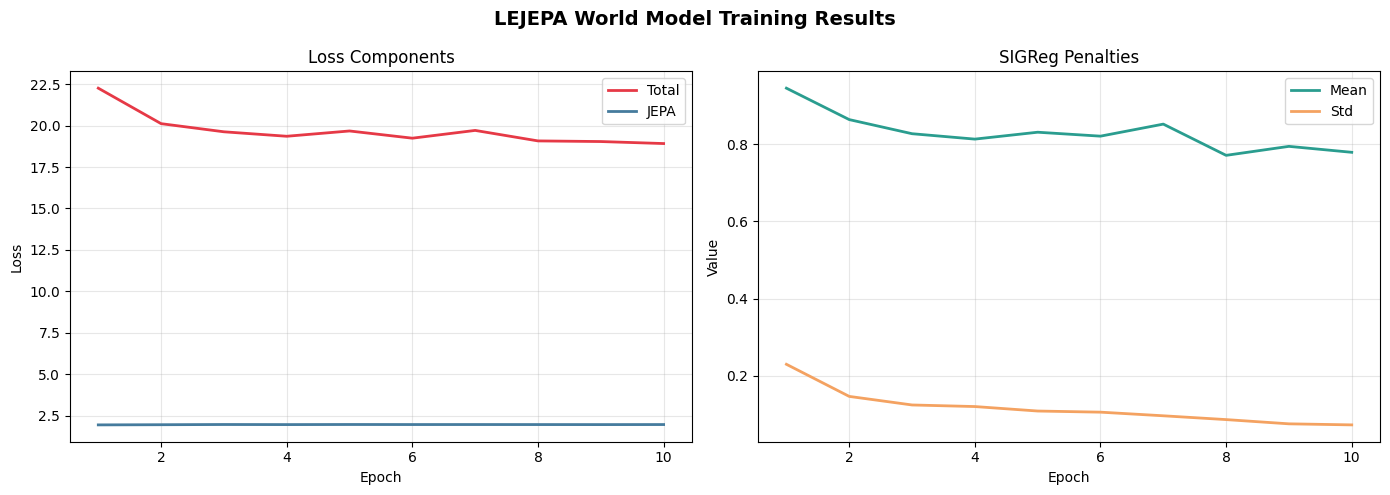


✅ Plot successfully forced to display and saved to 'forced_training_plot.png'


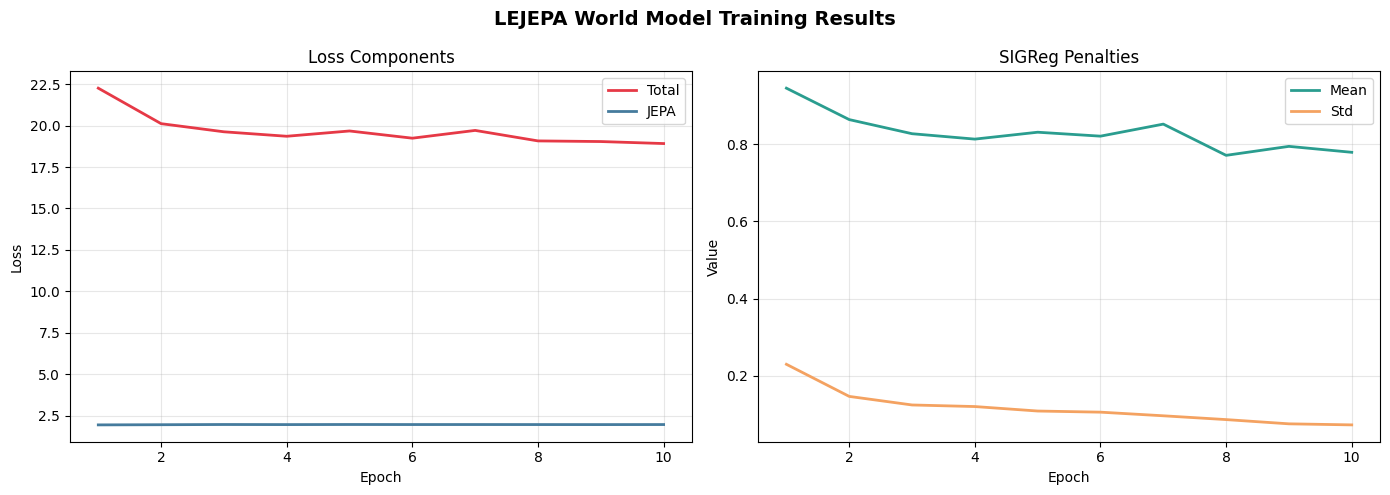

In [ ]:
# ── CELL 13: FORCED OUTPUT VERSION ───────────────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import display

# Step 1: Force the notebook to use its inline renderer
%matplotlib inline

try:
    if 'wm_history' not in locals() or not wm_history:
        print("❌ DATA ERROR: 'wm_history' is empty. You must run the training cell (Cell 6) first!")
    else:
        # Step 2: Create the plot
        epochs = list(range(1, len(wm_history) + 1))
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("LEJEPA World Model Training Results", fontsize=14, fontweight="bold")

        # Left: Losses
        ax = axes[0]
        for key, lbl, col in [("loss/total", "Total", "#E63946"), ("loss/jepa", "JEPA", "#457B9D")]:
            ax.plot(epochs, [h.get(key, 0) for h in wm_history], label=lbl, color=col, lw=2)
        ax.set(title="Loss Components", xlabel="Epoch", ylabel="Loss")
        ax.legend(); ax.grid(True, alpha=0.3)

        # Right: Penalties
        ax = axes[1]
        for key, lbl, col in [("sigreg/mean", "Mean", "#2A9D8F"), ("sigreg/std", "Std", "#F4A261")]:
            ax.plot(epochs, [h.get(key, 0) for h in wm_history], label=lbl, color=col, lw=2)
        ax.set(title="SIGReg Penalties", xlabel="Epoch", ylabel="Value")
        ax.legend(); ax.grid(True, alpha=0.3)

        plt.tight_layout()

        # Step 3: THE TRICK - Manually force the figure to display
        display(fig)

        # Also save it just in case
        plt.savefig("forced_training_plot.png")
        print("\n✅ Plot successfully forced to display and saved to 'forced_training_plot.png'")

except Exception as e:
    print(f"❌ CRITICAL ERROR: {e}")